In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns",None)
df=pd.read_csv("../data/raw/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [5]:
#Converting into percentages
df["Machine failure"].value_counts(normalize=True)*100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [6]:
#checking distribution of machine types
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [7]:
#Checking whether the failure depends on machine type
pd.crosstab(df["Type"],df["Machine failure"])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


We cannot conclude that L machines are more  failure from these counts because there are more L machines than H and M machines
So we calculate failure rate in each type

In [8]:
pd.crosstab(df["Type"],df["Machine failure"],normalize="index")*100

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


In [9]:
#to check How frequently does each type of machine failure occur
failure_modes=["TWF","HDF","PWF","OSF","RNF"]
df[failure_modes].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

HDF is most common failure mode
OSF and PWF are also realatively frequent
TWF and RNF occur less often

In [10]:
pd.crosstab(df["Machine failure"],df[failure_modes].sum(axis=1))

col_0,0,1,2,3
Machine failure,,,,
0,9643,18,0,0
1,9,306,23,1


Failure Mode Consistency Check 
We found that some rows have a mismatch between the failure-mode flags and the Machine failure column.
For example, some rows have a failure-mode column sum of 1 or more but are still labeled as Machine failure = 0.

In [11]:
#Inspect rows where a failure mode exists but Machine Failure = 0
df[(df["Machine failure"]==0) & (df[failure_modes].sum(axis=1)>0) ]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,M16081,M,297.0,308.3,1399,46.4,132,0,0,0,0,0,1
1302,1303,L48482,L,298.6,309.8,1505,45.7,144,0,0,0,0,0,1
1748,1749,H31162,H,298.4,307.7,1626,31.1,166,0,0,0,0,0,1
2072,2073,L49252,L,299.6,309.5,1570,35.5,189,0,0,0,0,0,1
2559,2560,L49739,L,299.3,309.0,1447,50.4,140,0,0,0,0,0,1
3065,3066,M17925,M,300.1,309.2,1687,27.7,95,0,0,0,0,0,1
3452,3453,H32866,H,301.6,310.5,1602,32.3,2,0,0,0,0,0,1
5471,5472,L52651,L,302.7,312.3,1346,61.2,170,0,0,0,0,0,1
5489,5490,L52669,L,302.6,312.1,1499,35.0,215,0,0,0,0,0,1
5495,5496,H34909,H,302.9,312.5,1357,55.0,12,0,0,0,0,0,1


In [12]:
#Inspect rows where a failure mode does not exist but Machine Failure = 1
df[(df["Machine failure"]==1) & (df[failure_modes].sum(axis=1)==0)]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1437,1438,H30851,H,298.8,309.9,1439,45.2,40,1,0,0,0,0,0
2749,2750,M17609,M,299.7,309.2,1685,28.9,179,1,0,0,0,0,0
4044,4045,M18904,M,301.9,310.9,1419,47.7,20,1,0,0,0,0,0
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,1,0,0,0,0,0
5536,5537,M20396,M,302.3,311.8,1363,54.0,119,1,0,0,0,0,0
5941,5942,L53121,L,300.6,310.7,1438,48.5,78,1,0,0,0,0,0
6478,6479,L53658,L,300.5,309.8,1663,29.1,145,1,0,0,0,0,0
8506,8507,L55686,L,298.4,309.6,1710,27.3,163,1,0,0,0,0,0
9015,9016,L56195,L,297.2,308.1,1431,49.7,210,1,0,0,0,0,0


We have inconsistencies in the dataset
Lets evaluate how much percent these inconsistencies acoount of the entire dataset

In [13]:
inconsitent=df[
    ((df["Machine failure"]==0) & (df[failure_modes].sum(axis=1)>0)) |
    ((df["Machine failure"]==1) & (df[failure_modes].sum(axis=1)==0))
]
print('No of inconsistent rows:')
print(len(inconsitent))
print('Percentage of inconsistent data:')
print((len(inconsitent)/len(df))*100)

No of inconsistent rows:
27
Percentage of inconsistent data:
0.27


Finding

27 rows (0.27%) showed a mismatch between Machine failure and the failure-mode flags. Since this is a very small portion of the dataset, these rows are retained for the main analysis.

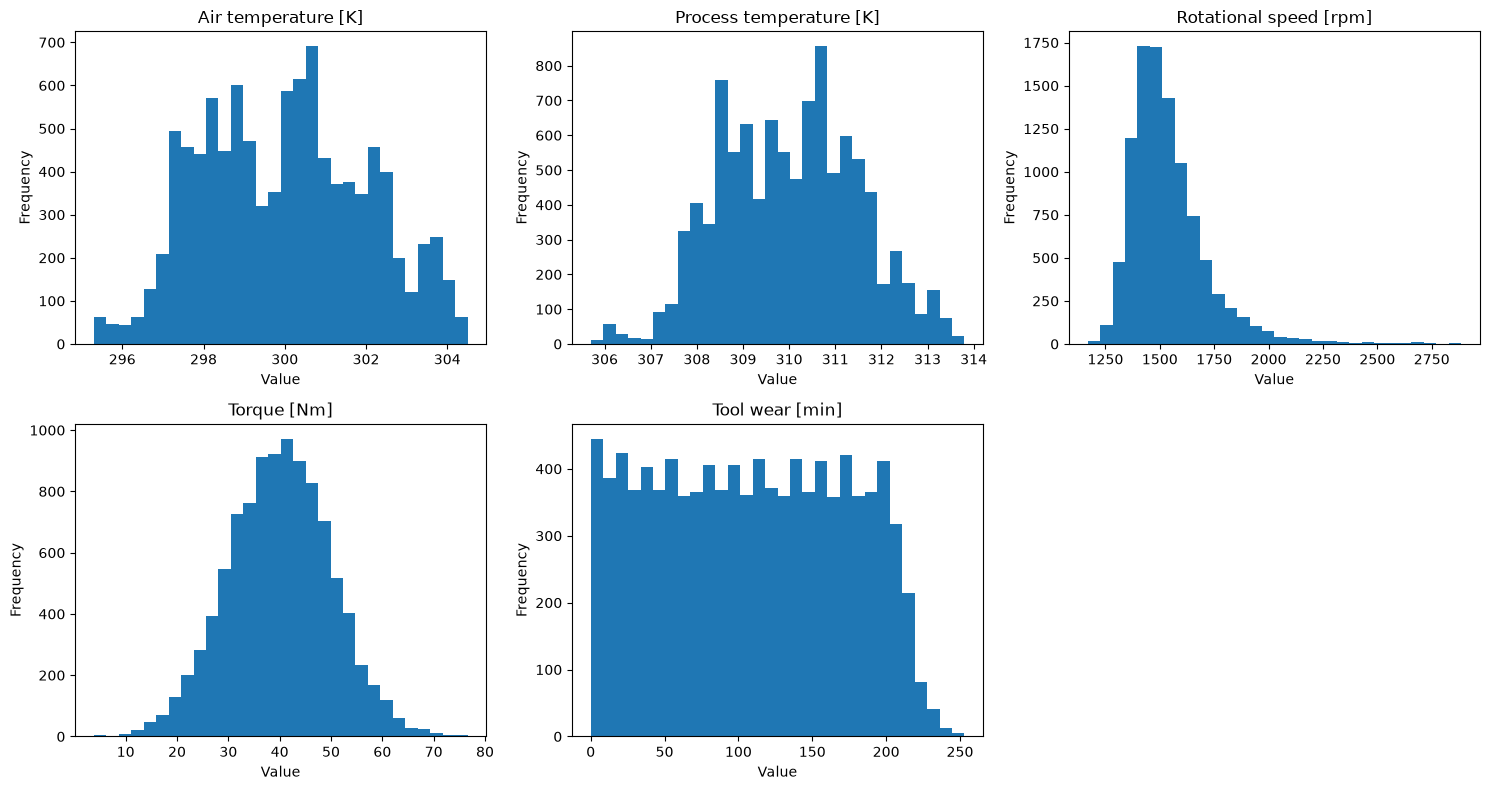

In [14]:
import matplotlib.pyplot as plt

sensor_cols=[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig,axes=plt.subplots(2,3,figsize=(15,8))
for ax,col in zip(axes.flatten(),sensor_cols):
    ax.hist(df[col],bins=30)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    
axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()

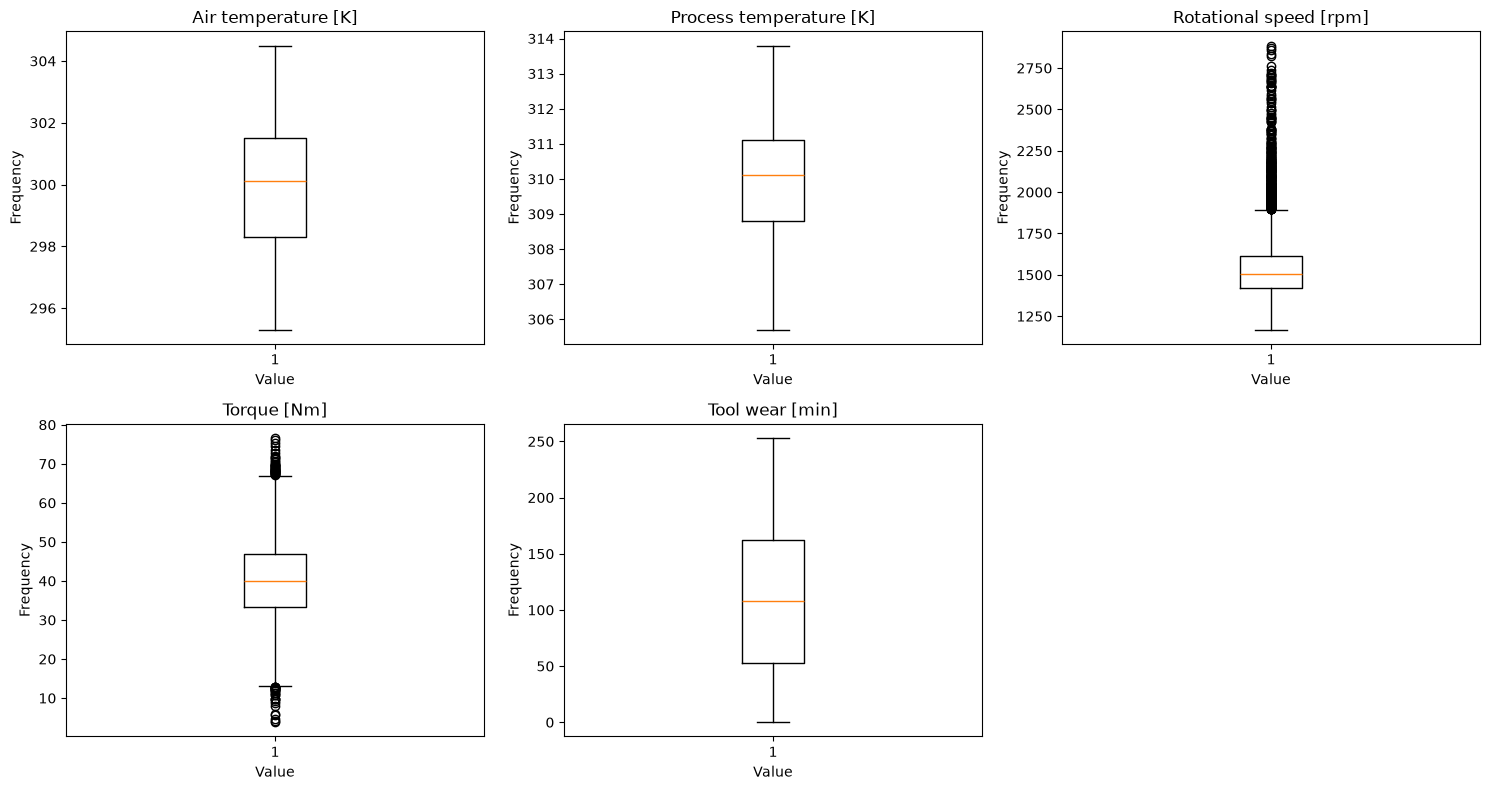

In [15]:
fig,axes=plt.subplots(2,3,figsize=(15,8))
for ax,col in zip(axes.flatten(),sensor_cols):
    ax.boxplot(df[col])
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    
axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()

Rotational speed shows numerous potential high-value outliers, while torque has some potential outliers at both extremes. Air temperature, process temperature, and tool wear do not show prominent outlier patterns.

Exploring whether sensor values behave differently for failed vs non failed machines 

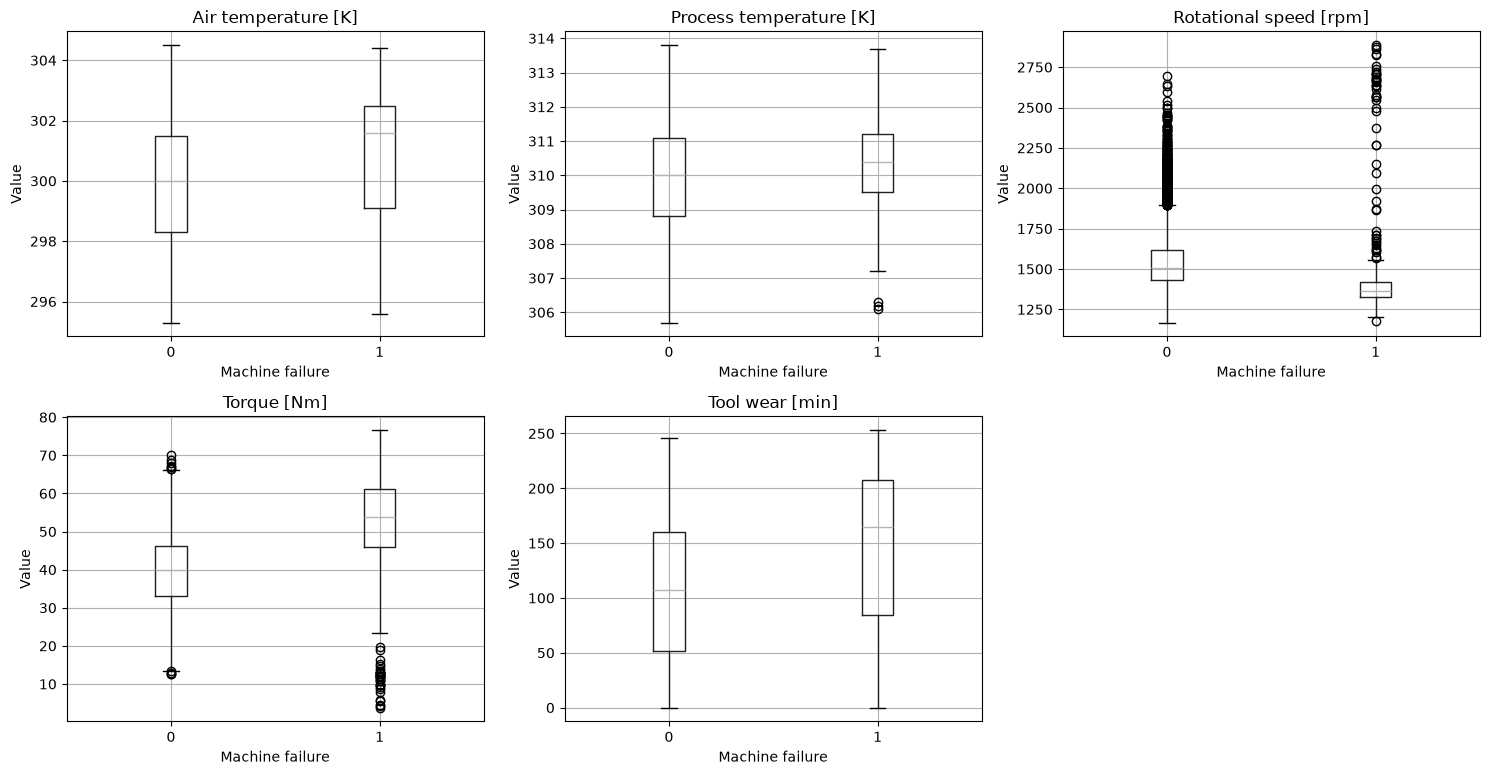

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), sensor_cols):
    df.boxplot(column=col, by="Machine failure", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Machine failure")
    ax.set_ylabel("Value")

axes.flatten()[-1].set_visible(False)

plt.suptitle("")
plt.tight_layout()
plt.show()

## Sensor Behavior by Machine Failure

We compared the sensor values for machines with and without failure.

- Air temperature is slightly higher for failed machines, but the difference is small.
- Process temperature looks mostly similar in both groups, with some outliers in the failure group.
- Rotational speed has a lower median for failed machines, but there are many outliers in both groups.
- Torque is noticeably higher for failed machines.
- Tool wear is also higher for failed machines.

From this comparison, torque and tool wear seem to show clearer differences between the two groups.

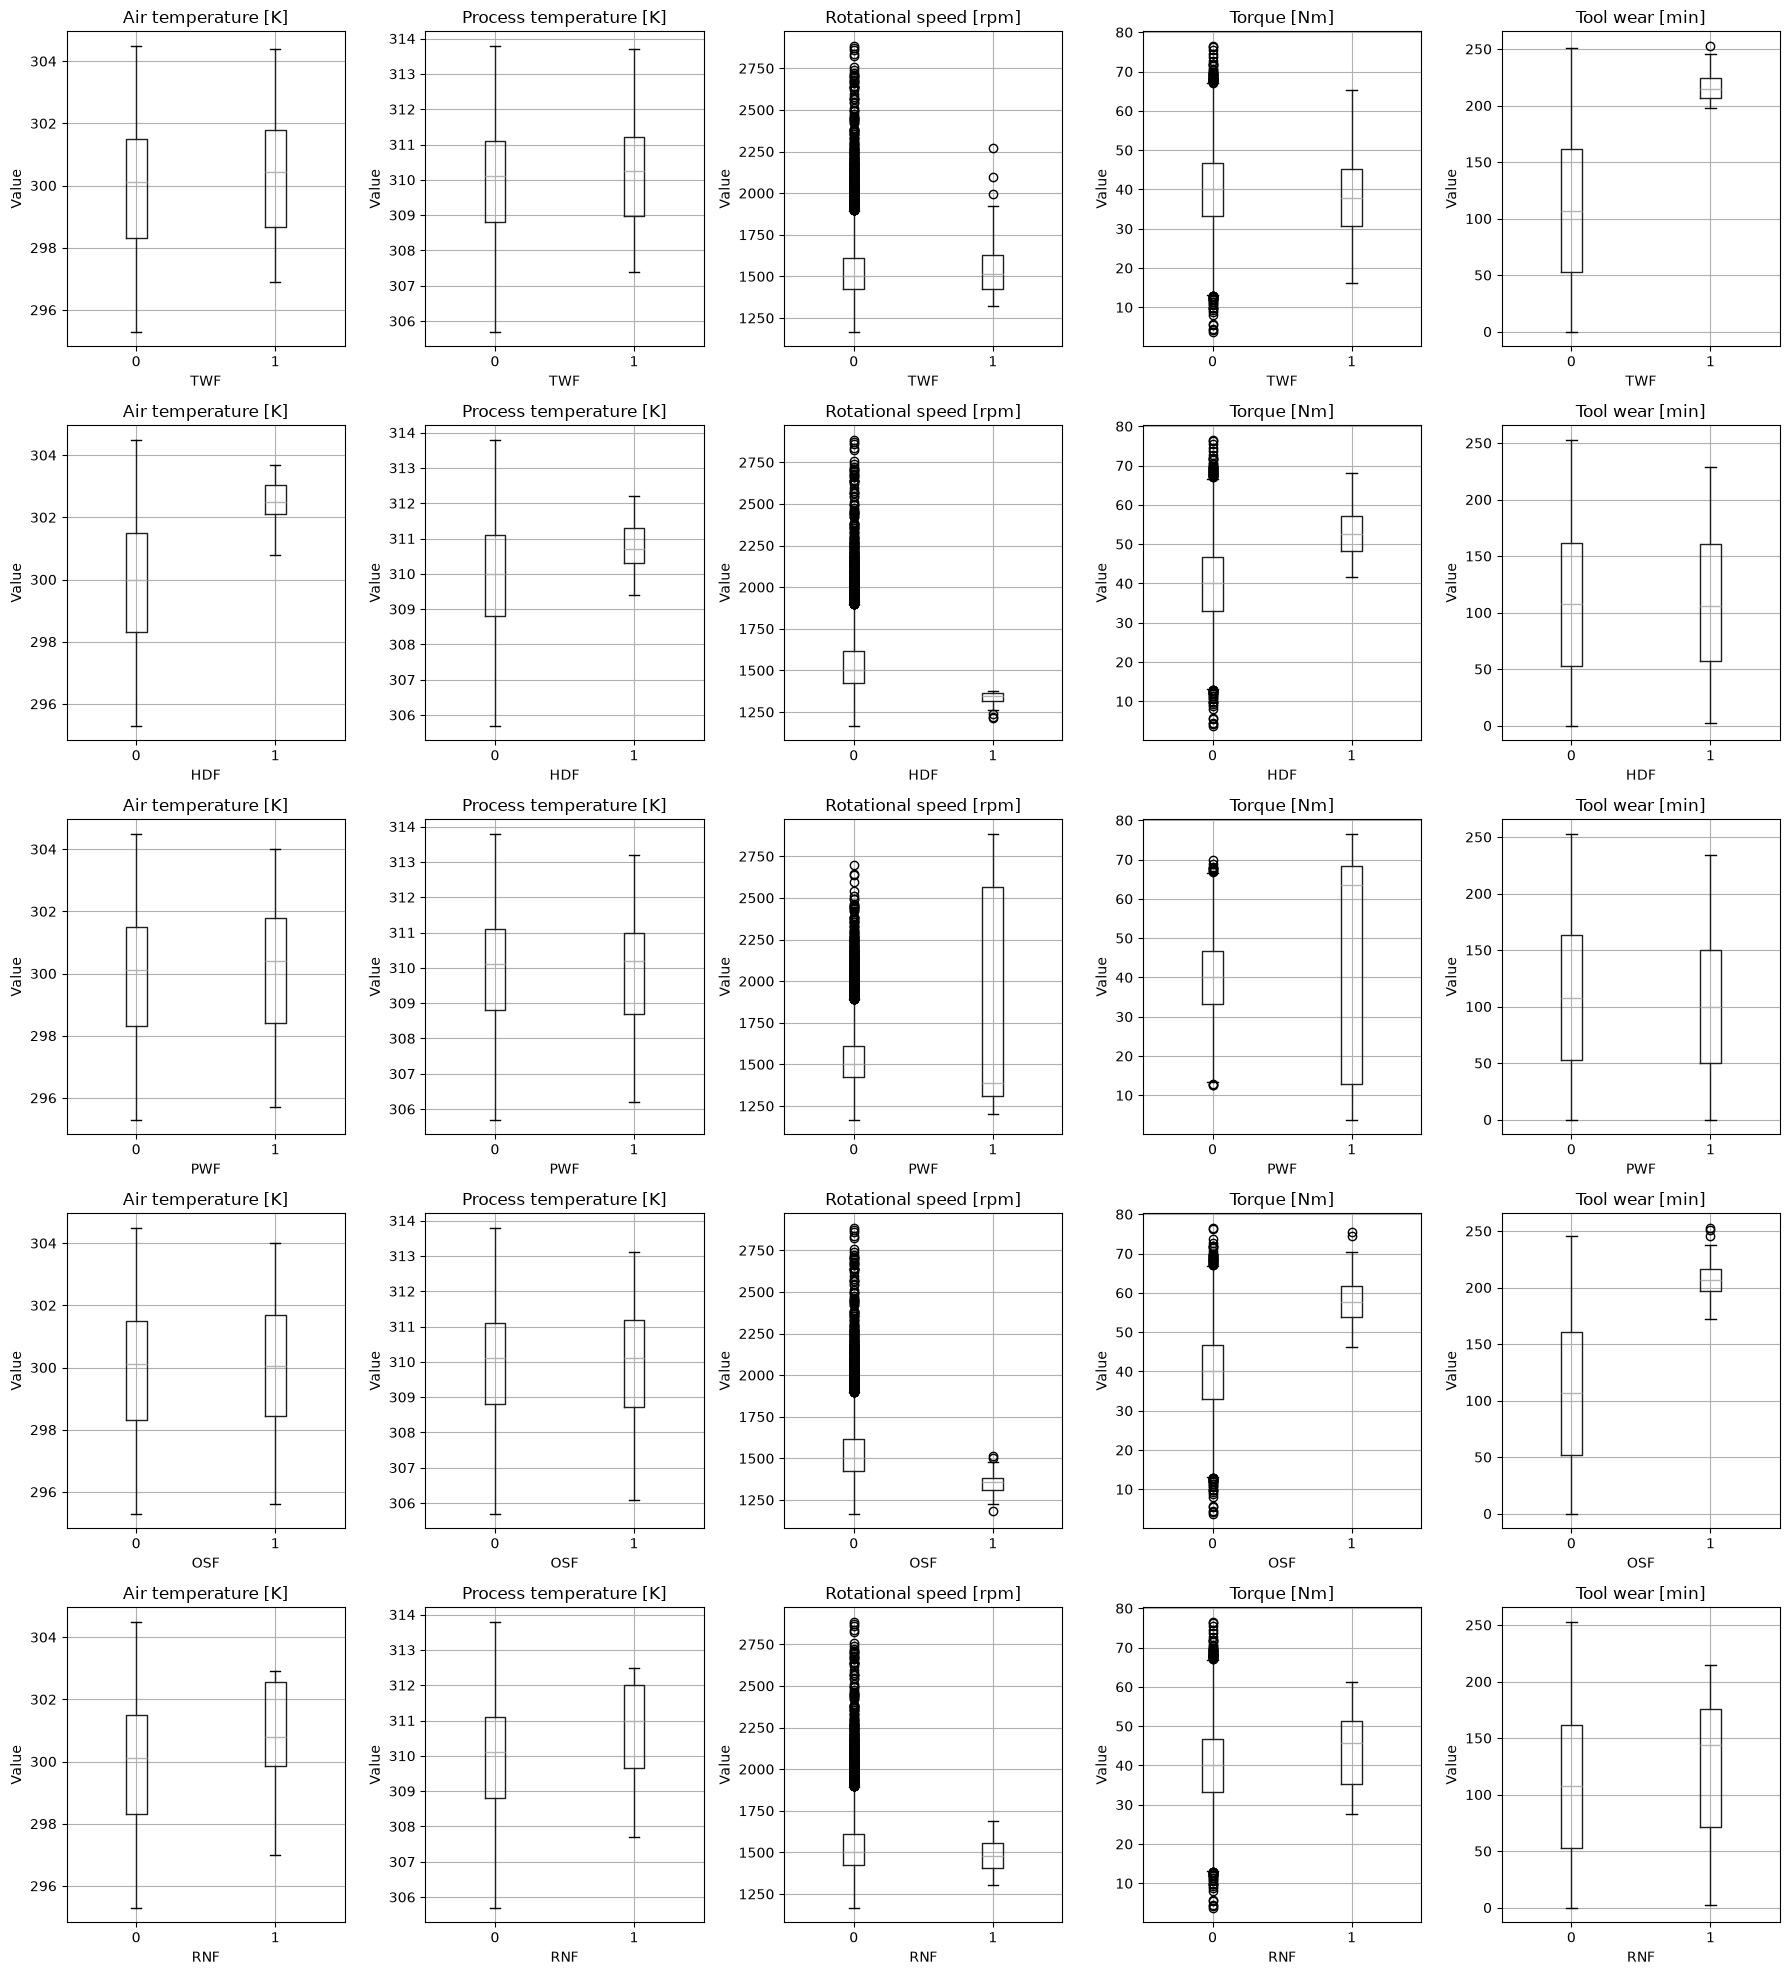

In [23]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

fig, axes = plt.subplots(5, 5, figsize=(18, 20))

for i, mode in enumerate(failure_modes):
    for j, col in enumerate(sensor_cols):
        df.boxplot(column=col, by=mode, ax=axes[i, j])
        axes[i, j].set_title(col)
        axes[i, j].set_xlabel(mode)
        axes[i, j].set_ylabel("Value")

plt.suptitle("")
plt.tight_layout()
plt.show()

Different failure modes appear to have different sensor patterns. For example, HDF is associated with higher temperatures and lower rotational speed, while OSF shows higher tool wear and torque.

In [25]:
corr_cols = sensor_cols + ["Machine failure"]
corr_matrix = df[corr_cols].corr()

corr_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


## Correlation Analysis

We checked the correlation between the sensor variables and machine failure.

- Air temperature and process temperature have a strong positive correlation (0.876).
- Rotational speed and torque have a strong negative correlation (-0.875).
- Torque has the highest correlation with machine failure (0.191), followed by tool wear (0.105).
- The other sensors have very weak correlation with machine failure.

The sensor variables are strongly related to each other in some cases, but no single sensor has a strong linear relationship with machine failure.

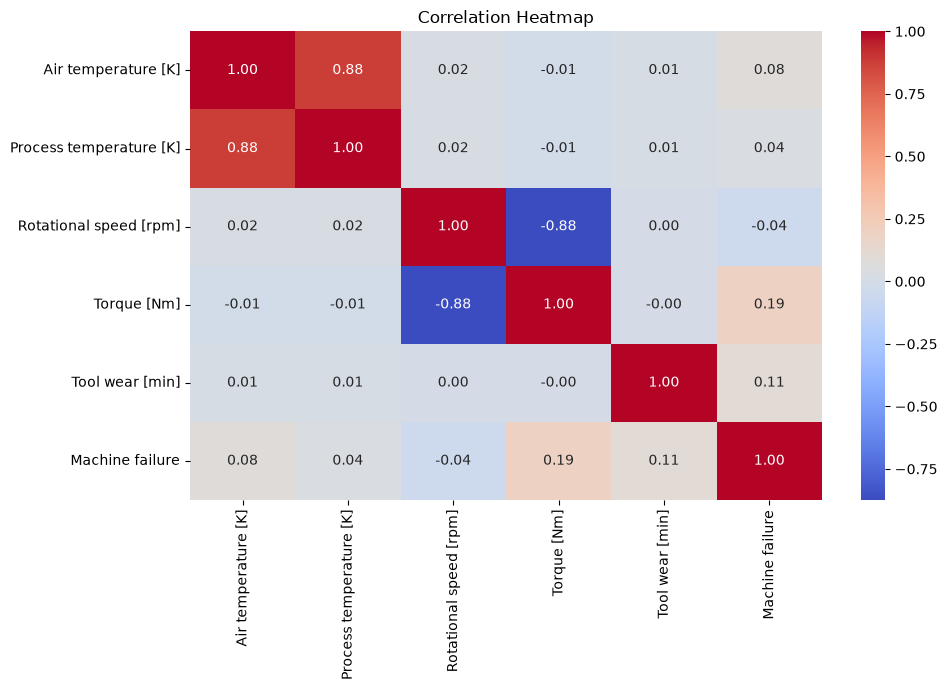

In [ ]:
#Visual representation of heatmap using seaborn
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [31]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [35]:
df["Machine failure"].unique()

array([0, 1])

In [36]:
df["Machine failure"].unique()

array([0, 1])

In [38]:
df[sensor_cols].agg(["min", "max","mean"])

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
min,295.30000,305.70000,1168.0000,3.80000,0.000
max,304.50000,313.80000,2886.0000,76.60000,253.000
mean,300.00493,310.00556,1538.7761,39.98691,107.951


## EDA Summary

- The dataset contains 10,000 records and there are no missing values or duplicate rows.
- Machine failure is highly imbalanced, with only 3.39% of the machines having a failure.
- The failure rate is slightly different across the three product quality types.
- Torque and tool wear show clearer differences between failed and non-failed machines.
- Some potential outliers were found, especially in rotational speed and torque, but they are not automatically treated as errors.
- Different failure modes show some differences in sensor behavior, but there is no clear pattern across all failure modes.
- Air temperature and process temperature have a strong positive correlation, while rotational speed and torque have a strong negative correlation.
- No single sensor has a strong linear correlation with machine failure.

Overall, the data looks clean enough to move to the next stage. The EDA suggests that machine failure is likely related to a combination of operating conditions rather than one sensor alone.